In [61]:
import pandas as pd
import numpy as np
df = pd.read_csv('Phishing_URL_ds_cleaned.csv')

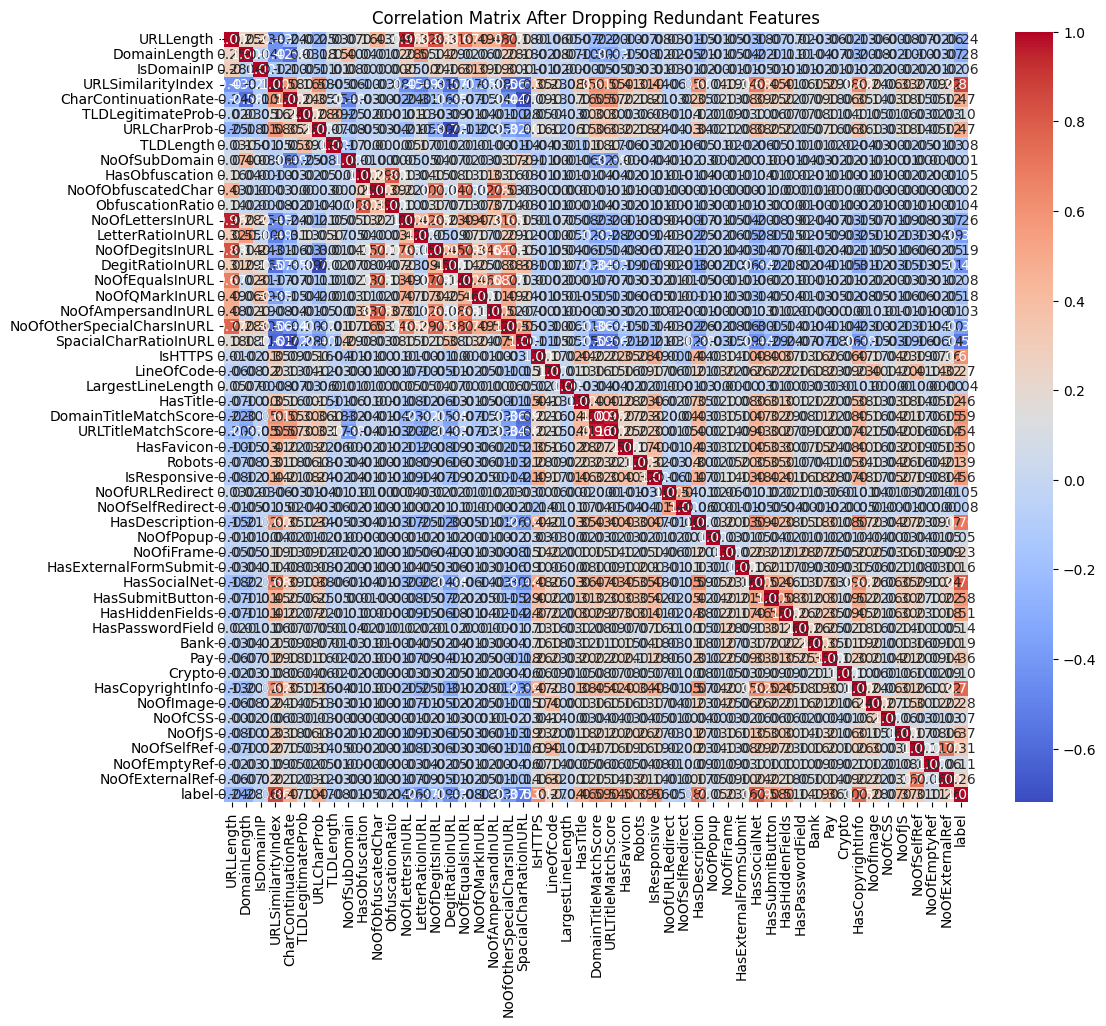

In [ ]:
# I want to look at the correlation matrix again after feature engineering
import seaborn as sns
import matplotlib.pyplot as plt

df_for_heatmap = df.select_dtypes(include=[np.number])
corr_matrix = df_for_heatmap.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix After Dropping Redundant Features')
plt.show()

for URLSimilartyindex
it would use the Levenshtein Distance algorithm to compare the input URL against a cached list of the Top 500 targeted brands (PayPal, Gmail, Netflix, etc.).

In [37]:
#we need to check similarity index feature importance with a simple model 
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Test 1: Using ONLY URLSimilarityIndex
X_simple = df[['URLSimilarityIndex']]
y = df['label']

clf = DecisionTreeClassifier(max_depth=2) # Very simple model
clf.fit(X_simple, y)
print(f"Accuracy with ONLY SimilarityIndex: {accuracy_score(y, clf.predict(X_simple)):.4f}") #woow this is too high

Accuracy with ONLY SimilarityIndex: 0.9911


we need to drop because, the feature URLSimilarityIndex is not just correlated with the label; it is practically the definition of the label for this dataset.

In [63]:
df = df.drop(columns=['URLSimilarityIndex'])

In [39]:
# check the HasSocialNet.. to drop or not
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Test 1: Using ONLY HasSocialNetWord
X_simple = df[['HasSocialNet']]
y = df['label']

clf = DecisionTreeClassifier(max_depth=2) # Very simple model
clf.fit(X_simple, y)
print(f"Accuracy with ONLY HasSocialNet: {accuracy_score(y, clf.predict(X_simple)):.4f}")
#it is okey to keep HasSocialNet feature since lower than 0.9 accuracy

Accuracy with ONLY HasSocialNet: 0.8861


In [40]:
# check the urltitlematchscore.. to drop or not
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Test 1: Using ONLY URLTitleMatchScore
X_simple = df[['URLTitleMatchScore']]
y = df['label']

clf = DecisionTreeClassifier(max_depth=2) # Very simple model
clf.fit(X_simple, y)
print(f"Accuracy with ONLY URLTitleMatchScore: {accuracy_score(y, clf.predict(X_simple)):.4f}")
#it is okey to keep URLTitleMatchScore feature since lower than 0.9 accuracy

Accuracy with ONLY URLTitleMatchScore: 0.7736


Feature Creation

I look into data and talk with gemini (https://gemini.google.com/share/e89cd886988c)
 I find it there could be a good feature creations to help the model understand and for better visulazation with t-SNE...

In [64]:
df.columns

Index(['URLLength', 'DomainLength', 'IsDomainIP', 'CharContinuationRate',
       'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain',
       'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio',
       'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL',
       'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL',
       'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL',
       'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength',
       'HasTitle', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon',
       'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect',
       'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit',
       'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields',
       'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo',
       'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef',
       'NoOfExternalRef', 'TLD_Final', 'label'],
      dtype='object')

In [65]:
# 1. External Reference Ratio
df['External_Ref_Ratio'] = df['NoOfExternalRef'] / (df['NoOfSelfRef'] + df['NoOfEmptyRef'] + df['NoOfExternalRef'] + 1)

# 2. Dangerous Form Submission (Boolean interaction)
df['Unsafe_Form_Submit'] = ((df['HasPasswordField'] == 1) & (df['HasExternalFormSubmit'] == 1)).astype(int)

# 3. Sensitive Topic Aggregation
df['Sensitive_Keywords_Count'] = df['Bank'] + df['Pay'] + df['Crypto']

# 4. Domain Weight
df['Domain_Weight'] = df['DomainLength'] / df['URLLength']

Scaling 
(I will apply robust scaling if there is so much outlier 
if there is moderaable I will oick standartscaling
the reason I choose these 2 is centring my variable at 0 so PCA will performs better )

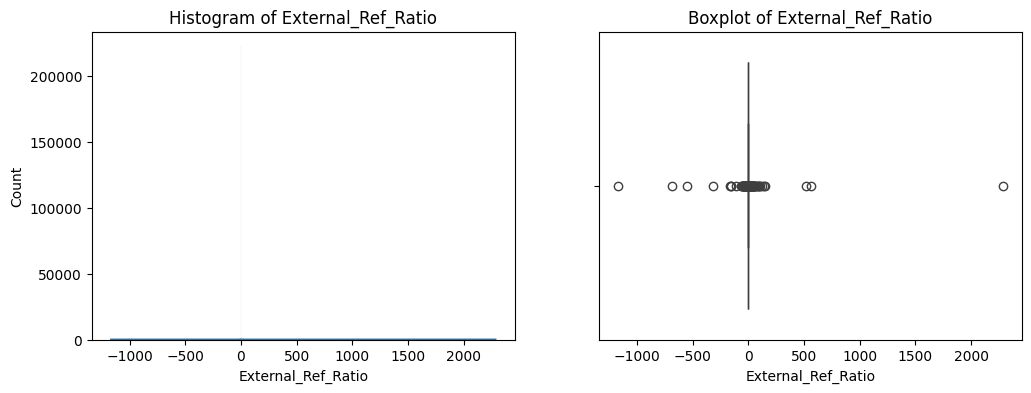

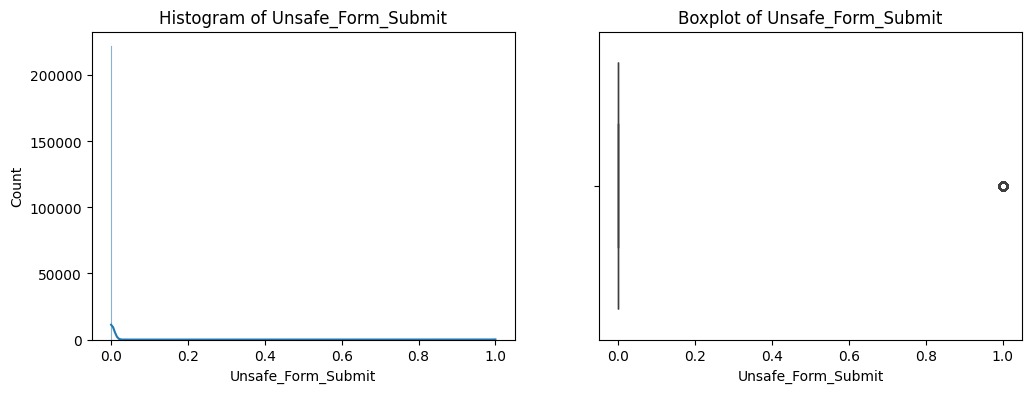

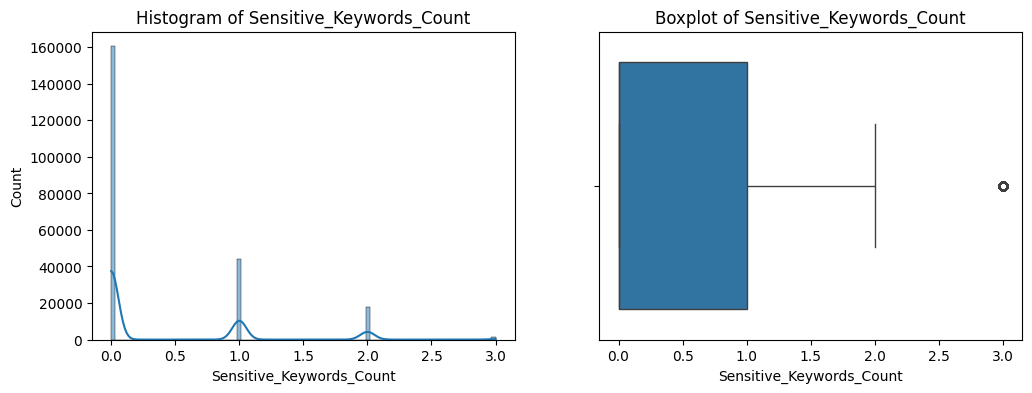

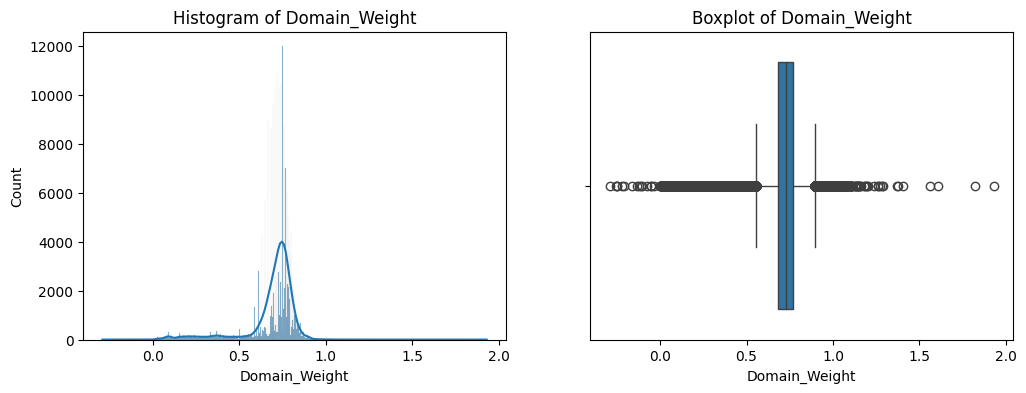

In [66]:
# I need to check their boxplot to see the distributions and apply scaling if needed
# I want to check individually also
for col in df[['External_Ref_Ratio','Unsafe_Form_Submit','Sensitive_Keywords_Count','Domain_Weight']]:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(df[col], ax=axes[0], kde=True)
    sns.boxplot(x=df[col], ax=axes[1])
    axes[0].set_title(f'Histogram of {col}')
    axes[1].set_title(f'Boxplot of {col}')
    plt.show()

In [44]:
#check the Domain_Weight feature shapiro wilk test
from scipy.stats import shapiro
stat, p = shapiro(df['Domain_Weight'])
print(f'Shapiro-Wilk Test: Statistics={stat:.4f}, p-value={p:.4f}')

if p < 0.05:
    print("Domain_Weight feature is not normally distributed (reject H0)")
else:
    print("Domain_Weight feature is normally distributed (fail to reject H0)")

Shapiro-Wilk Test: Statistics=0.7219, p-value=0.0000
Domain_Weight feature is not normally distributed (reject H0)


/Users/akkus/Documents/GitHub/Phishing-URL--Website--Detection/.venv/lib/python3.14/site-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 224012.
  res = hypotest_fun_out(*samples, **kwds)


*Mixed Scaling Technique*:
we will apply standard scaling to binary features and others robust (they have a lots of outlier) gemini talk: https://gemini.google.com/share/83c294eaeeb7

In [68]:
df.describe()
for col in df.columns:
    print(f"{col}: min={df[col].min()}, max={df[col].max()}")

URLLength: min=13.0, max=6097.0
DomainLength: min=-5.246577257393721, max=110.0
IsDomainIP: min=0, max=1
CharContinuationRate: min=-0.0926357036578797, max=2.508900537268158
TLDLegitimateProb: min=-0.1432875034826973, max=0.5548152229784692
URLCharProb: min=-0.0004473674306178, max=0.090823664
TLDLength: min=1.7788832279543554, max=13.0
NoOfSubDomain: min=-0.6300870549545836, max=10.0
HasObfuscation: min=0, max=1
NoOfObfuscatedChar: min=-6.133933043515209, max=447.0
ObfuscationRatio: min=-0.0164583869804491, max=0.348
NoOfLettersInURL: min=-91.57640230815625, max=5191.0
LetterRatioInURL: min=0.0, max=1.6728986990590728
NoOfDegitsInURL: min=-4.147539688556968, max=2011.0
DegitRatioInURL: min=-0.3017019636970599, max=0.684
NoOfEqualsInURL: min=-1.6397281162937416, max=165.0
NoOfQMarkInURL: min=-0.7774266394922961, max=5.198864721199492
NoOfAmpersandInURL: min=-1.811917073893116, max=149.0
NoOfOtherSpecialCharsInURL: min=-1.127387294713337, max=470.0
SpacialCharRatioInURL: min=-1.12638527

In [70]:
#first I will apply power transform to make the distribution more gaussian like then I will apply robust scaler (I check on EDA part the distributions of these features are right skewed)
from sklearn.preprocessing import PowerTransformer, RobustScaler , StandardScaler

#list if features to transform and scale
features_to_transform = ['URLLength','DomainLength','CharContinuationRate','TLDLegitimateProb','URLCharProb','LetterRatioInURL','SpacialCharRatioInURL',
                          'External_Ref_Ratio','Sensitive_Keywords_Count','Domain_Weight']
features_to_scale_std = ['IsDomainIP', 'HasObfuscation', 'IsHTTPS', 'HasTitle', 'HasFavicon', 'Robots', 'IsResponsive', 'HasDescription', 'HasSocialNet', 
                         'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo', 'Unsafe_Form_Submit']
features_to_scale_robust = ['URLLength','DomainLength','CharContinuationRate','TLDLegitimateProb','URLCharProb','LetterRatioInURL','SpacialCharRatioInURL',
                      'External_Ref_Ratio','Sensitive_Keywords_Count','Domain_Weight']
# Apply Power Transform
power_transformer = PowerTransformer()
df[features_to_transform] = power_transformer.fit_transform(df[features_to_transform])
# Apply Robust Scaler
std_scaler = StandardScaler()
df[features_to_scale_std] = std_scaler.fit_transform(df[features_to_scale_std])
robust_scaler = RobustScaler()
df[features_to_scale_robust] = robust_scaler.fit_transform(df[features_to_scale])

In [71]:
df.to_csv('Phishing_URL_ds_feature_engineered.csv', index=False)